<a href="https://colab.research.google.com/github/Zahab163/receipt_analyzer_ai/blob/main/receipt_analyzer_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Installing and uploading Libraries

In [ ]:
!pip install pytesseract
import cv2
import pytesseract
import pandas as pd
import re

In [ ]:
!pip install easyocr


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 30.7 MB/s eta 0:00:00


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteSUPERMARKET
4tovc
Pasaden Cx 91105
Doz FREE RANGE EGG
ORGANIC MILK
54.1
SBUX FRECH RO4S] WL $8
HJ8.0lAL
TOTAl
517 Ot
PURCHASE
DEATT To91
Auth #143987
Coahiet
44oo
1l - Zur
01.28
PhRer/Scq "140967
Tacm 204650
IAEnb
ICecc
Scoucocr
934519
ITEH
STEP IE
11/21/2019
01.28
PK 4130 1> 1041 2675


## Grayscale Conversion (Image Preprocessing)
- Load the receipt image.
- Convert it to grayscale to simplify the image and highlight text.
- Save or display the processed image for further steps like noise reduction, contrast enhancement, and thresholding.


### Grayscale Conversion with OpenCV





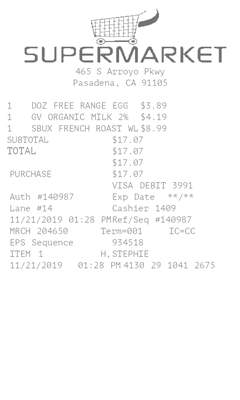

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

# Load the receipt image
image = cv2.imread("/content/GroceryReceipt.jpg")

# Convert to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Save or display
cv2.imwrite("receipt_gray.jpg", gray_image)
cv2_imshow(gray_image)

## Grayscale Conversion with Pillow (PIL)
(optional)

In [ ]:
from PIL import Image

# Load the receipt image
image = Image.open("/content/GroceryReceipt.jpg")

# Convert to grayscale
gray_image = image.convert("L")

# Save or show
gray_image.save("receipt_gray.jpg")
gray_image.show()

### Typical Preprocessing Pipeline (before OCR)
You’ll usually combine grayscale with other steps:


In [ ]:
# Noise reduction
import numpy as np
gray_image_np = np.array(gray_image) # Convert PIL Image to NumPy array
denoised = cv2.medianBlur(gray_image_np, 3)

# Contrast enhancement
enhanced = cv2.equalizeHist(denoised)

# Thresholding (binarization)
_, thresholded = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

cv2.imwrite("receipt_preprocessed.jpg", thresholded)

True

###Receipt Image Handling
- Accept receipt images as input.
- Apply preprocessing (noise reduction, grayscale, contrast enhancement, thresholding).
- Use OCR to extract text (items, quantities, prices, totals).


In [ ]:
import easyocr
reader = easyocr.Reader(['en'])
results = reader.readtext("/content/receipt_preprocessed.jpg")
for res in results:
    print(res[1])

##Text Structuring & Cleanup
- Parse OCR output into structured fields (item, price, quantity).
- Detect and correct OCR errors.
- Standardize data for consistency.


 ## Expense Categorization
- Assign items to categories (snacks, dairy, meat, bakery, etc.).
- Compute totals per category and overall spending.


## Spending Insights
- Calculate category percentages of total spending.
- Identify overspending or anomalies.


In [ ]:
import cv2
import pytesseract
import pandas as pd
import re

def preprocess_image(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    thresh = cv2.adaptiveThreshold(
        blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 11, 2
    )
    return thresh

def extract_text(image):
    text = pytesseract.image_to_string(image, lang="eng")
    return text

def parse_receipt_text(text):
    items = []
    lines = text.split("\n")
    for line in lines:
        line = line.strip()
        if not line:
            continue
        # Look for item + price inline (e.g., "Coffee $3.50")
        inline_match = re.match(r"(.+?)\s+\$?(\d+\.\d{1,2})", line)
        if inline_match:
            item, price = inline_match.groups()
            items.append({"Item": item.strip(), "Price": float(price)})
        else:
            # Look for standalone price lines
            price_match = re.match(r"\$?(\d+\.\d{1,2})", line)
            if price_match:
                price = price_match.group(1)
                items.append({"Item": "Unknown", "Price": float(price)})
    return pd.DataFrame(items)

def categorize_items(df):
    categories = {
        "egg":"Dairy", "milk":"Dairy", "bread":"Bakery", "coffee":"Beverages"
    }
    df["Category"] = df["Item"].apply(
        lambda x: next((cat for key, cat in categories.items() if key in x.lower()), "Other")
    )
    return df

def analyze_spending(df):
    category_totals = df.groupby("Category")["Price"].sum()
    total = df["Price"].sum()
    percentages = (category_totals / total) * 100
    return category_totals, percentages

if __name__ == "__main__":
    image_path = "/content/GroceryReceipt.jpg"
    processed_img = preprocess_image(image_path)
    text = extract_text(processed_img)
    print("Raw OCR Output:\n", text)

    df = parse_receipt_text(text)
    if not df.empty:
        df = categorize_items(df)
        totals, percentages = analyze_spending(df)

        print("\nStructured Data:\n", df)
        print("\nCategory Totals:\n", totals)
        print("\nPercentages:\n", percentages)
    else:
        print("\nNo items matched the parsing pattern. Try adjusting regex or preprocessing.")

Raw OCR Output:
 od
SUPERMARKET

2 Arrore Poy
Panatints Co S103

POR HaKE tance td $8.29

 

 

aed Lene?
rere
TULUZOLD e128 Prtetrieq Lean?
OMe Termeeh Tote
Uh teqwence NIE
TOT. M STINE

SURES Gian atte ay ise 2075

 


Structured Data:
                 Item  Price Category
0  POR HaKE tance td   8.29    Other

Category Totals:
 Category
Other    8.29
Name: Price, dtype: float64

Percentages:
 Category
Other    100.0
Name: Price, dtype: float64


## Why Grayscale?
- Simplifies the image (removes color info).
- Makes text stand out for OCR.
- Reduces computational load.


**Note:** Why we did not worked on preprocessed recipt because our receipt is already in gray , added the process cause asked in the process.


### cetogirizing our own manual recipt and spending insights rather than recipt pics:

In [ ]:
# Expense Categorization

# Example structured OCR output
receipt_data = [
    {"item": "Milk", "price": 2.5, "quantity": 1},
    {"item": "Bread", "price": 1.8, "quantity": 2},
    {"item": "Chicken", "price": 6.0, "quantity": 1},
    {"item": "Chips", "price": 3.0, "quantity": 3},
]

# Define categories with keywords
categories = {
    "dairy": ["milk", "cheese", "yogurt", "butter"],
    "bakery": ["bread", "cake", "bun", "pastry"],
    "meat": ["chicken", "beef", "mutton", "fish"],
    "snacks": ["chips", "biscuits", "cookies", "chocolate"],
}

def categorize_item(item_name):
    """Return category based on item keywords."""
    item_name = item_name.lower()
    for category, keywords in categories.items():
        if any(keyword in item_name for keyword in keywords):
            return category
    return "other"

def categorize_expenses(receipt):
    """Categorize items and compute totals per category."""
    category_totals = {}
    overall_total = 0

    for entry in receipt:
        category = categorize_item(entry["item"])
        total_price = entry["price"] * entry["quantity"]
        overall_total += total_price

        if category not in category_totals:
            category_totals[category] = 0
        category_totals[category] += total_price

    return category_totals, overall_total

# Run categorization
category_totals, overall_total = categorize_expenses(receipt_data)

# Display results
print("Category Totals:")
for cat, total in category_totals.items():
    print(f"{cat}: ${total:.2f}")

print(f"\nOverall Spending: ${overall_total:.2f}")

Category Totals:
dairy: $2.50
bakery: $3.60
meat: $6.00
snacks: $9.00

Overall Spending: $21.10


## AI-Powered Financial Guidance
1. Prepare Spending Summary
Format your categorized totals into a readable string for the LLM.


In [ ]:
category_totals = {
    "dairy": 2.5,
    "bakery": 3.6,
    "meat": 6.0,
    "snacks": 9.0
}
overall_total = sum(category_totals.values())

spending_summary = "\n".join([f"{cat}: ${total:.2f}" for cat, total in category_totals.items()])

## 2. Build the Prompt for the LLM
Create a clear instruction that tells the model to act like a financial advisor.


In [ ]:
prompt = f"""
You are a financial advisor AI. The user has uploaded a receipt and here is the spending breakdown:

{spending_summary}
Overall Total: ${overall_total:.2f}

Please provide personalized budgeting advice:
- Highlight overspending categories.
- Suggest practical ways to reduce costs.
- Give general financial wellness tips.
"""

In [ ]:
#Install python-dotenv
!pip install python-dotenv






In [ ]:
# importing library
from dotenv import load_dotenv
import os


In [ ]:
# Load environment variables from your file
# Verify the key is loaded


!pip install python-dotenv
from dotenv import load_dotenv

load_dotenv("/content/e.env")

True

In [ ]:
#Install the Gemini SDK

!pip install google-generativeai

## Use the Gemini Client



In [ ]:
import google.generativeai as genai
import os

# Load key from environment
api_key = os.getenv("GEMINI_API_KEY")

# Configure client
genai.configure(api_key=api_key)

# Find an available model that supports generateContent
selected_model_name = None
for m in genai.list_models():
  if 'generateContent' in m.supported_generation_methods:
    selected_model_name = m.name
    break

if selected_model_name:
    print(f"Using model: {selected_model_name}")
    model = genai.GenerativeModel(selected_model_name)
    response = model.generate_content("Give me budgeting advice for groceries under $100.")
    print(response.text)
else:
    print("No model found that supports 'generateContent'. Please check your API key and region.")


Using model: models/gemini-2.5-flash
Budgeting for groceries under $100 can be challenging, but it's absolutely doable with a little planning and smart shopping. Here's a comprehensive guide:

## Phase 1: Planning & Prep (Before You Shop)

This is the most crucial phase for saving money!

1.  **Do a Pantry & Fridge Audit:**
    *   Before you even *think* about a grocery list, see what you already have. What needs to be used up? What staples are running low? This prevents buying duplicates and reduces waste.
    *   *Example:* If you have half a bag of lentils, plan a lentil soup. If you have some wilting spinach, plan a stir-fry or smoothie.

2.  **Meal Plan Strategically:**
    *   **Plan Around Sales & Flyers:** Check weekly flyers from your local stores *before* planning. Build your meals around items that are on sale (especially proteins and staple produce).
    *   **Simple, Budget-Friendly Meals:** Focus on meals that use inexpensive ingredients:
        *   **Grains:** Rice, pa